# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Azizah Salma Ayunisa Purnomo
- **Email:** almaayunisa8@gmail.com
- **ID Dicoding:** almaayunisa

## Menentukan Pertanyaan Bisnis

- Kapan waktu puncak (peak time) terjadinya volume pesanan tertinggi berdasarkan jam dan hari selama 2017-2018?
- Bagaimana distribusi atau rata-rata payment value (nilai transaksi) untuk masing-masing jenis metode pembayaran yang digunakan pelanggan sepanjang tahun 2017-2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [3]:
os.listdir(path)

['olist_customers_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_products_dataset.csv',
 'olist_geolocation_dataset.csv',
 'product_category_name_translation.csv',
 'olist_orders_dataset.csv',
 'olist_order_payments_dataset.csv']

**Insight:**
- Dataset yang digunakan adalah dataset e commerce dari brazil dengan 9 file csv yang berisi informasi customer, seller, order, product, dan lokasi.

### Assessing Data

In [11]:
for csv in os.listdir(path):
    df = pd.read_csv(os.path.join(path, csv))
    print("-----------------------------------------------------------------------")
    print(f"Informasi file {csv}:")
    df.info()

    print(f"Head file {csv}:")
    print(df.head())

    print(f"Unique file {csv}:")
    print(df.nunique())

    print(f"Null in file {csv}:")
    print(df.isnull().sum())

    print(f"Duplicate in file {csv}:")
    print(df.duplicated().sum())
    print("-----------------------------------------------------------------------")


-----------------------------------------------------------------------
Informasi file olist_customers_dataset.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Head file olist_customers_dataset.csv:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c510

**Insight:**
- File olist_order_reviews_dataset.csv memiliki null value pada kolom review_comment_title dengan total 87656 dan review_comment_message dengan total 58247, untuk duplikat tidak ada
- File olist_products_dataset.csv memiliki 610 null pada kolom product_category_name, product_name_lenght, product_description_lenght, dan product_photos_qty. Terdapat 2 null value pada kolom product_weight_g,product_length_cm, product_height_cm, dan product_width_cm untuk duplikat tidak ada
- File olist_orders_dataset.csv memiliki 160 null value pada kolom order_approved_at, 1783 pada kolom order_delivered_carrier_date, dan 2965 pada kolom order_delivered_customer_date untuk duplikat tidak ada
- File selain diatas tidak memiliki null value dan duplikat.


### Cleaning Data

In [25]:
output_path = "dataset"
os.makedirs(output_path, exist_ok=True)

for csv in os.listdir(path):
    if not csv.endswith('.csv'):
        continue

    filepath = os.path.join(path, csv)
    df = pd.read_csv(filepath)

    if csv == "olist_order_reviews_dataset.csv":
        df = df.drop(columns=["review_comment_title", "review_comment_message"])
        df = df.dropna()

    elif csv == "olist_orders_dataset.csv":
        df = df.dropna(subset=["order_id", "customer_id", "order_status",
                                "order_purchase_timestamp", "order_estimated_delivery_date"])

    else:
        df = df.dropna()

    df = df.drop_duplicates()
    df.to_csv(os.path.join(output_path, csv), index=False)

orders      = pd.read_csv(f"{output_path}/olist_orders_dataset.csv")
customers   = pd.read_csv(f"{output_path}/olist_customers_dataset.csv")
order_items = pd.read_csv(f"{output_path}/olist_order_items_dataset.csv")
order_pays  = pd.read_csv(f"{output_path}/olist_order_payments_dataset.csv")
order_revs  = pd.read_csv(f"{output_path}/olist_order_reviews_dataset.csv")
products    = pd.read_csv(f"{output_path}/olist_products_dataset.csv")
sellers     = pd.read_csv(f"{output_path}/olist_sellers_dataset.csv")
translation = pd.read_csv(f"{output_path}/product_category_name_translation.csv")
geolocation = pd.read_csv(f"{output_path}/olist_geolocation_dataset.csv")

valid_customer_ids = customers["customer_id"]
orders = orders[orders["customer_id"].isin(valid_customer_ids)]

valid_order_ids = orders["order_id"]
order_items = order_items[order_items["order_id"].isin(valid_order_ids)]
order_pays  = order_pays[order_pays["order_id"].isin(valid_order_ids)]
order_revs  = order_revs[order_revs["order_id"].isin(valid_order_ids)]

valid_seller_ids  = sellers["seller_id"]
valid_product_ids = products["product_id"]
order_items = order_items[order_items["seller_id"].isin(valid_seller_ids)]
order_items = order_items[order_items["product_id"].isin(valid_product_ids)]

valid_categories = translation["product_category_name"]
products = products[products["product_category_name"].isin(valid_categories)]

orders.to_csv(f"{output_path}/olist_orders_dataset.csv", index=False)
customers.to_csv(f"{output_path}/olist_customers_dataset.csv", index=False)
order_items.to_csv(f"{output_path}/olist_order_items_dataset.csv", index=False)
order_pays.to_csv(f"{output_path}/olist_order_payments_dataset.csv", index=False)
order_revs.to_csv(f"{output_path}/olist_order_reviews_dataset.csv", index=False)
products.to_csv(f"{output_path}/olist_products_dataset.csv", index=False)
sellers.to_csv(f"{output_path}/olist_sellers_dataset.csv", index=False)
translation.to_csv(f"{output_path}/product_category_name_translation.csv", index=False)
geolocation.to_csv(f"{output_path}/olist_geolocation_dataset.csv", index=False)

print(f"orders: {len(orders)}")
print(f"customers: {len(customers)}")
print(f"order_items: {len(order_items)}")
print(f"order_payments: {len(order_pays)}")
print(f"order_reviews: {len(order_revs)}")
print(f"products: {len(products)}")
print(f"sellers: {len(sellers)}")

orders: 99441
customers: 99441
order_items: 111046
order_payments: 103886
order_reviews: 99224
products: 32327
sellers: 3095


In [27]:
for csv in os.listdir(path):
    df = pd.read_csv(os.path.join(output_path, csv))
    print("-----------------------------------------------------------------------")
    print(f"Informasi file {csv}:")
    df.info()

    print(f"Head file {csv}:")
    print(df.head())

    print(f"Null in file {csv}:")
    print(df.isnull().sum())

    print(f"Duplicate in file {csv}:")
    print(df.duplicated().sum())
    print("-----------------------------------------------------------------------")

-----------------------------------------------------------------------
Informasi file olist_customers_dataset.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Head file olist_customers_dataset.csv:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c510

**Insight:**
- Tidak ada null dan duplikat lagi di dataset yang tersedia dan sudah disesuaikan dengan file csv lainnya agar tidak ada data yang kosong.

## Exploratory Data Analysis (EDA)

### Explore Distribusi

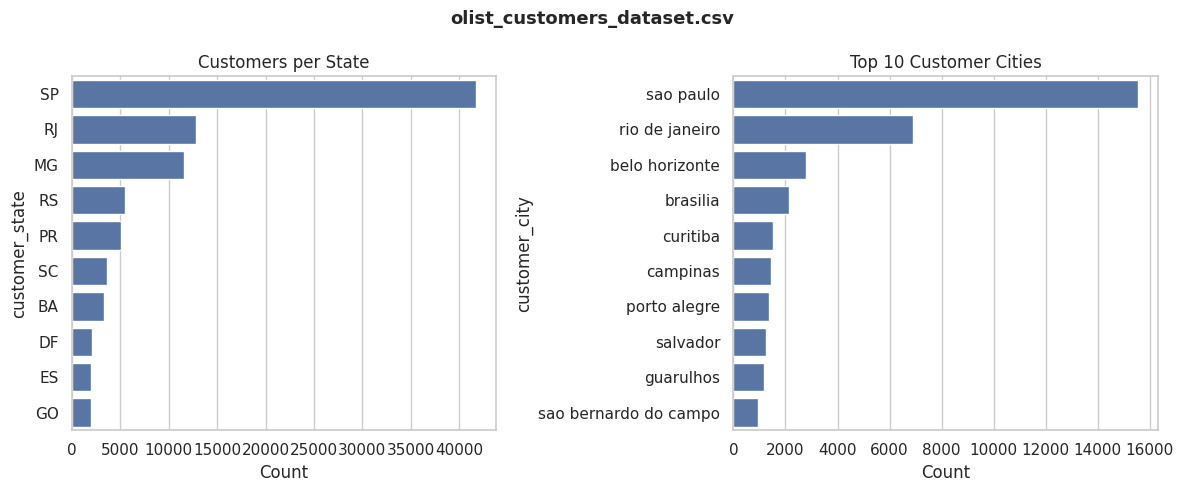

Saved: olist_customers_dataset_eda.png


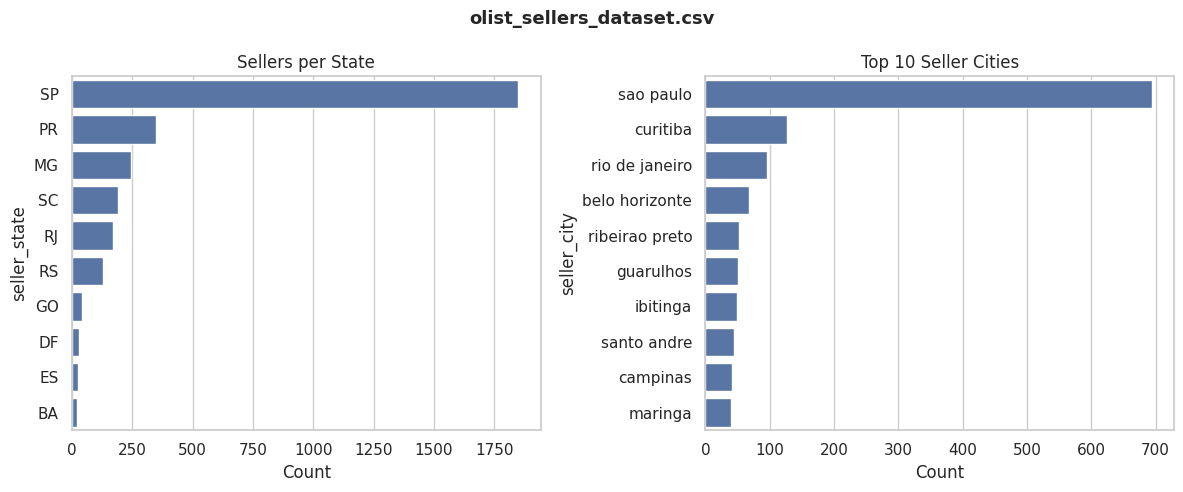

Saved: olist_sellers_dataset_eda.png


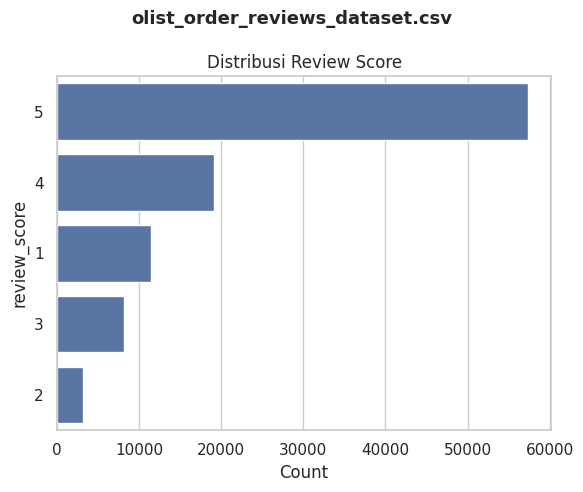

Saved: olist_order_reviews_dataset_eda.png


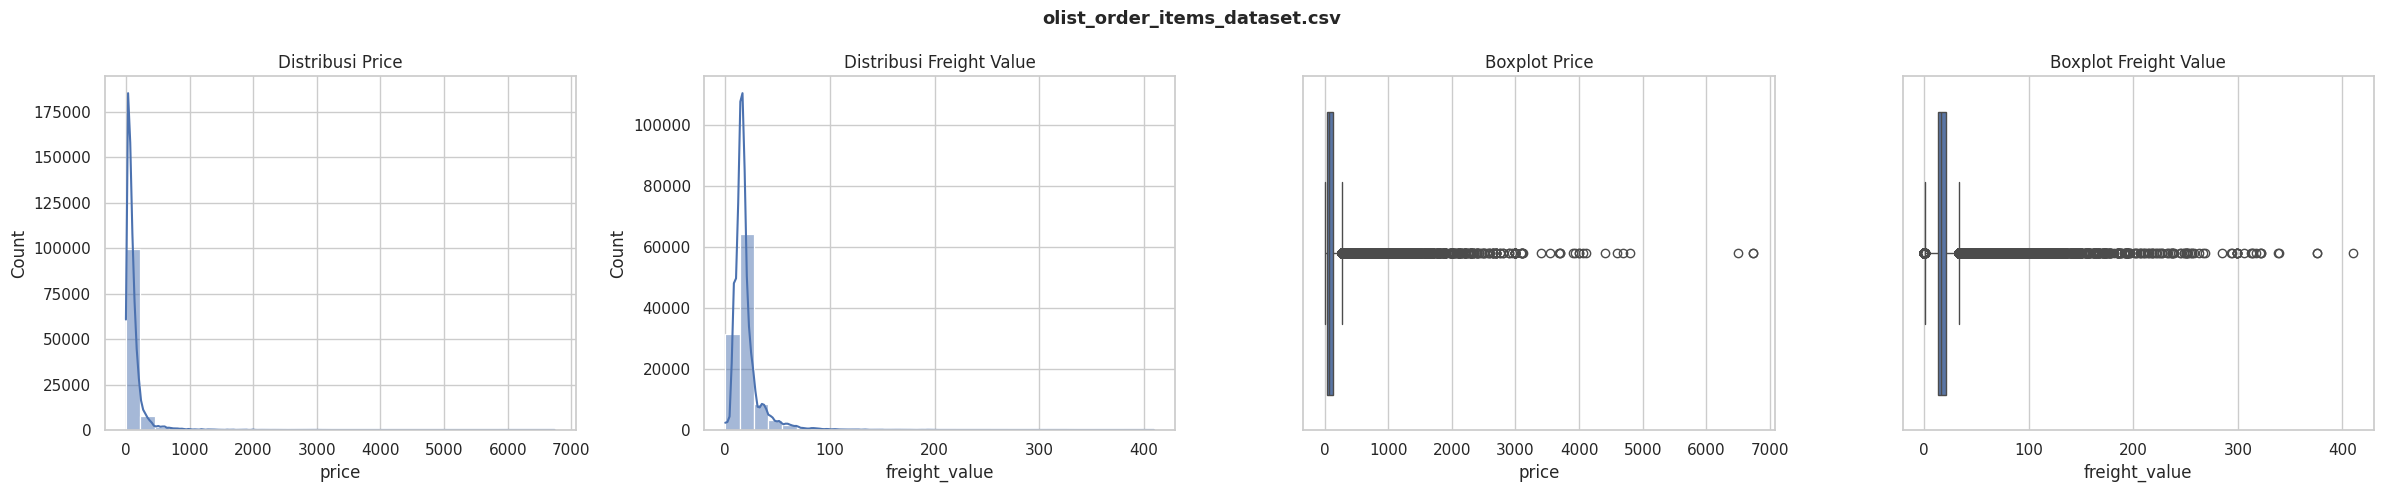

Saved: olist_order_items_dataset_eda.png


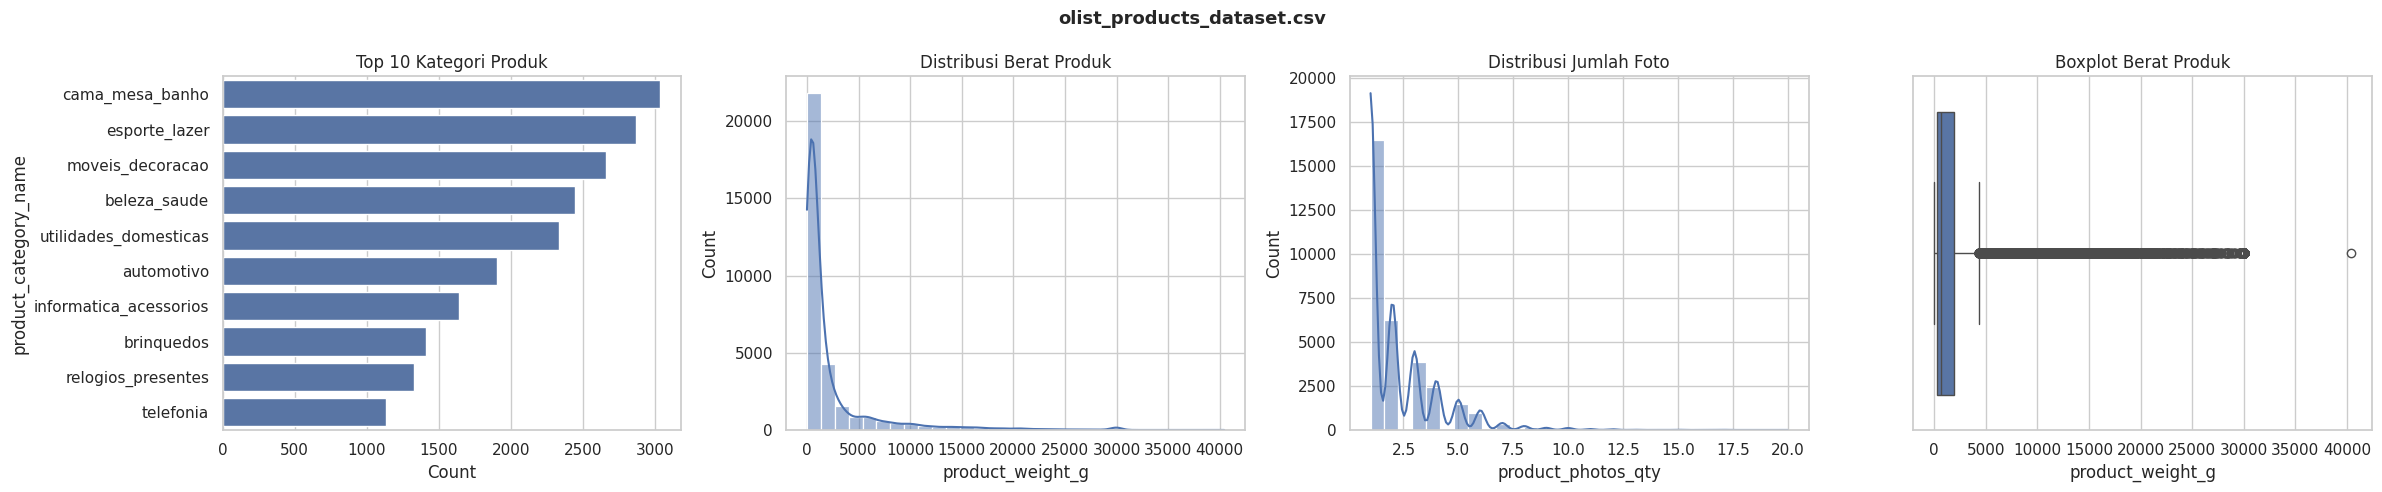

Saved: olist_products_dataset_eda.png


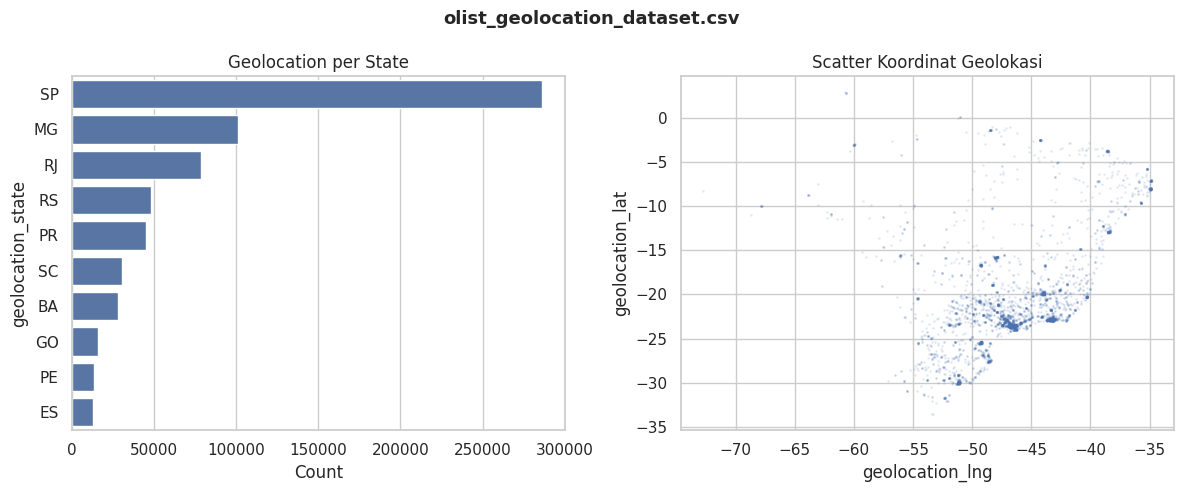

Saved: olist_geolocation_dataset_eda.png


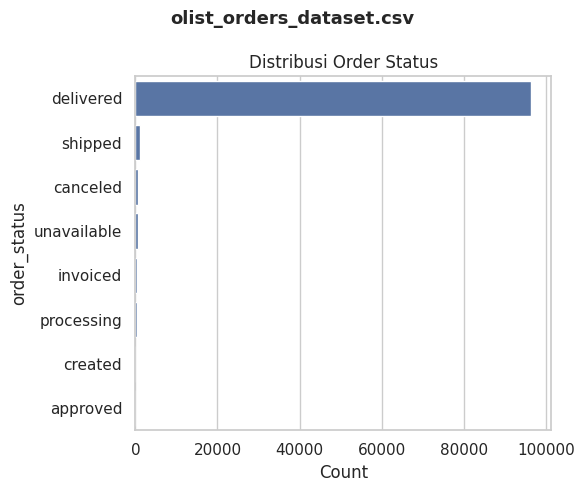

Saved: olist_orders_dataset_eda.png


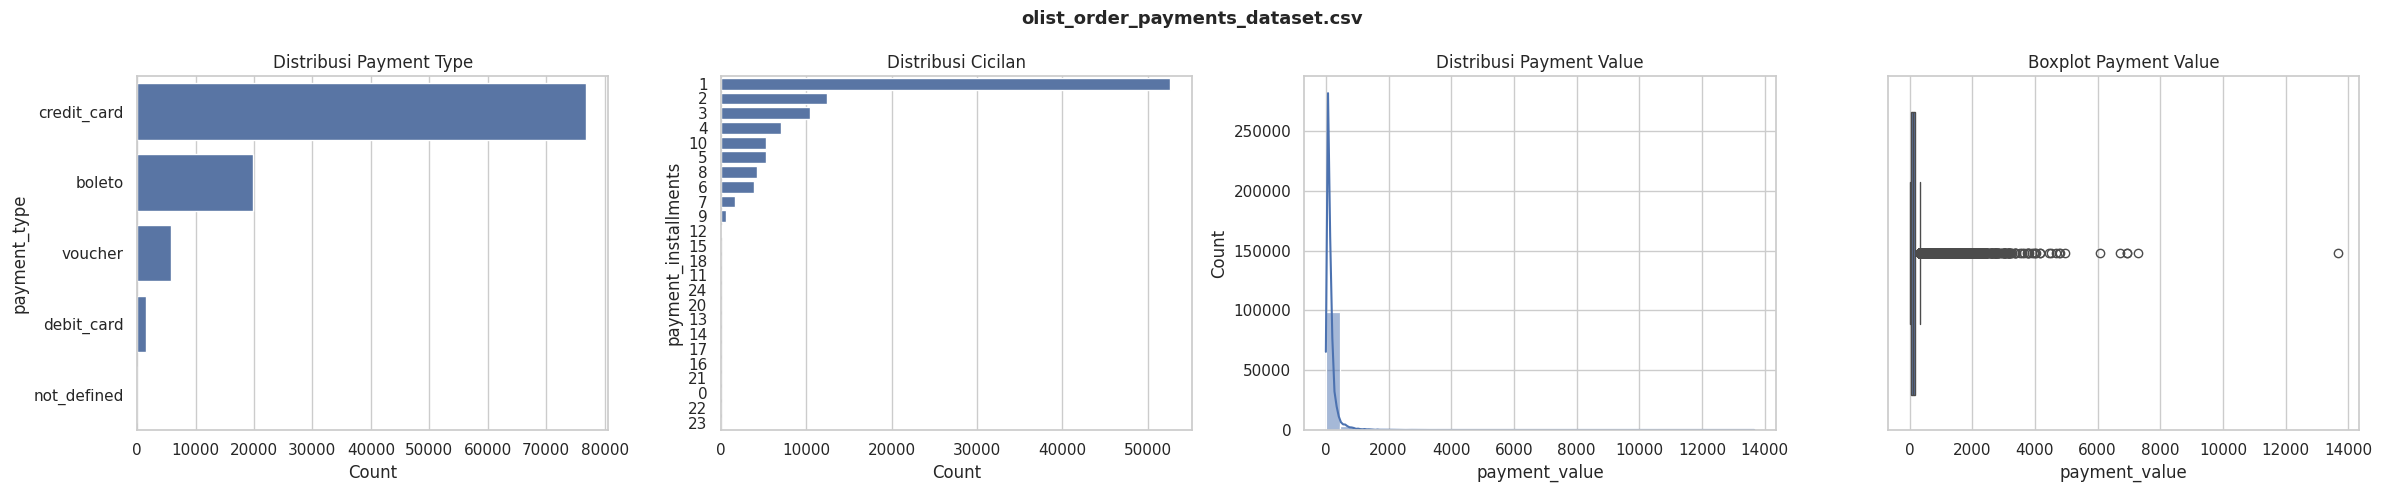

Saved: olist_order_payments_dataset_eda.png


In [30]:

sns.set_theme(style="whitegrid")

configs = {
    "olist_customers_dataset.csv": [
        {"type": "countplot", "col": "customer_state", "title": "Customers per State", "top": 10},
        {"type": "countplot", "col": "customer_city", "title": "Top 10 Customer Cities", "top": 10},
    ],
    "olist_sellers_dataset.csv": [
        {"type": "countplot", "col": "seller_state", "title": "Sellers per State", "top": 10},
        {"type": "countplot", "col": "seller_city", "title": "Top 10 Seller Cities", "top": 10},
    ],
    "olist_order_reviews_dataset.csv": [
        {"type": "countplot", "col": "review_score", "title": "Distribusi Review Score"},
    ],
    "olist_order_items_dataset.csv": [
        {"type": "hist", "col": "price", "title": "Distribusi Price"},
        {"type": "hist", "col": "freight_value", "title": "Distribusi Freight Value"},
        {"type": "box", "col": "price", "title": "Boxplot Price"},
        {"type": "box", "col": "freight_value", "title": "Boxplot Freight Value"},
    ],
    "olist_products_dataset.csv": [
        {"type": "countplot", "col": "product_category_name", "title": "Top 10 Kategori Produk", "top": 10},
        {"type": "hist", "col": "product_weight_g", "title": "Distribusi Berat Produk"},
        {"type": "hist", "col": "product_photos_qty", "title": "Distribusi Jumlah Foto"},
        {"type": "box", "col": "product_weight_g", "title": "Boxplot Berat Produk"},
    ],
    "olist_geolocation_dataset.csv": [
        {"type": "countplot", "col": "geolocation_state", "title": "Geolocation per State", "top": 10},
        {"type": "scatter", "col_x": "geolocation_lng", "col_y": "geolocation_lat", "title": "Scatter Koordinat Geolokasi", "sample": 5000},
    ],
    "olist_orders_dataset.csv": [
        {"type": "countplot", "col": "order_status", "title": "Distribusi Order Status"},
    ],
    "olist_order_payments_dataset.csv": [
        {"type": "countplot", "col": "payment_type", "title": "Distribusi Payment Type"},
        {"type": "countplot", "col": "payment_installments", "title": "Distribusi Cicilan"},
        {"type": "hist", "col": "payment_value", "title": "Distribusi Payment Value"},
        {"type": "box", "col": "payment_value", "title": "Boxplot Payment Value"},
    ],
}

for filename, charts in configs.items():
    filepath = os.path.join(output_path, filename)
    if not os.path.exists(filepath):
        continue

    df = pd.read_csv(filepath)
    n = len(charts)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    fig.suptitle(filename, fontsize=13, fontweight="bold")

    for ax, chart in zip(axes, charts):
        ctype = chart["type"]

        if ctype == "countplot":
            col = chart["col"]
            top = chart.get("top")
            if top:
                order = df[col].value_counts().iloc[:top].index
            else:
                order = df[col].value_counts().index
            sns.countplot(data=df, y=col, order=order, ax=ax)
            ax.set_title(chart["title"])
            ax.set_xlabel("Count")
            ax.set_ylabel(col)

        elif ctype == "hist":
            col = chart["col"]
            sns.histplot(df[col], bins=30, kde=True, ax=ax)
            ax.set_title(chart["title"])

        elif ctype == "box":
            col = chart["col"]
            sns.boxplot(x=df[col], ax=ax)
            ax.set_title(chart["title"])

        elif ctype == "scatter":
            sample = chart.get("sample", len(df))
            dfs = df.sample(min(sample, len(df)), random_state=42)
            ax.scatter(dfs[chart["col_x"]], dfs[chart["col_y"]], alpha=0.1, s=1)
            ax.set_title(chart["title"])
            ax.set_xlabel(chart["col_x"])
            ax.set_ylabel(chart["col_y"])

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, filename.replace(".csv", "_eda.png")), dpi=100)
    plt.show()
    print(f"Saved: {filename.replace('.csv', '_eda.png')}")

**Insight:**

**Customers & Sellers**
- Pelanggan dan penjual terkonsentrasi di São Paulo (SP), jauh melampaui state lain, mengindikasikan dominasi ekonomi e-commerce di wilayah tenggara Brazil
- Kota terbesar pelanggan: São Paulo, Rio de Janeiro, Belo Horizonte, konsisten dengan pusat populasi Brazil
- Penjual juga didominasi SP, diikuti PR dan MG, menunjukkan supply chain yang terpusat

**Review Score**
- Review score didominasi nilai 5, diikuti 4, kepuasan pelanggan secara umum tinggi
- Score 1 lebih banyak dari score 2 dan 3, pola umum di rating platform, pelanggan yang kecewa cenderung memberi nilai ekstrem

**Harga & Ongkos Kirim**
- Distribusi price sangat right-skewed, mayoritas produk di bawah 1.000, dengan outlier ekstrem hingga 7.000
- Freight value juga right-skewed, mayoritas di bawah 50 dengan outlier hingga 400
- Boxplot keduanya menunjukkan banyak outlier signifikan.

**Produk**
- Kategori terbanyak: cama_mesa_banho (perlengkapan rumah), esporte_lazer, moveis_decoracao
- Berat produk mayoritas di bawah 5.000 gram, distribusi right-skewed dengan outlier hingga 40.000 gram
- Jumlah foto produk mayoritas 1-3 foto

**Order Status**
- Hampir seluruh order berstatus delivered  karena data merupakan historis
- Status lain (shipped, canceled, unavailable) sangat kecil proporsinya.

**Payment**
- Credit card mendominasi jauh dibanding metode lain, boleto di posisi kedua, debit card sangat sedikit
- Cicilan paling umum adalah 1x (bayar penuh), diikuti cicilan 2-10x
- Payment value right-skewed, mayoritas transaksi di bawah 500 dengan outlier hingga 14.000
- Ada kategori not_defined di payment type.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

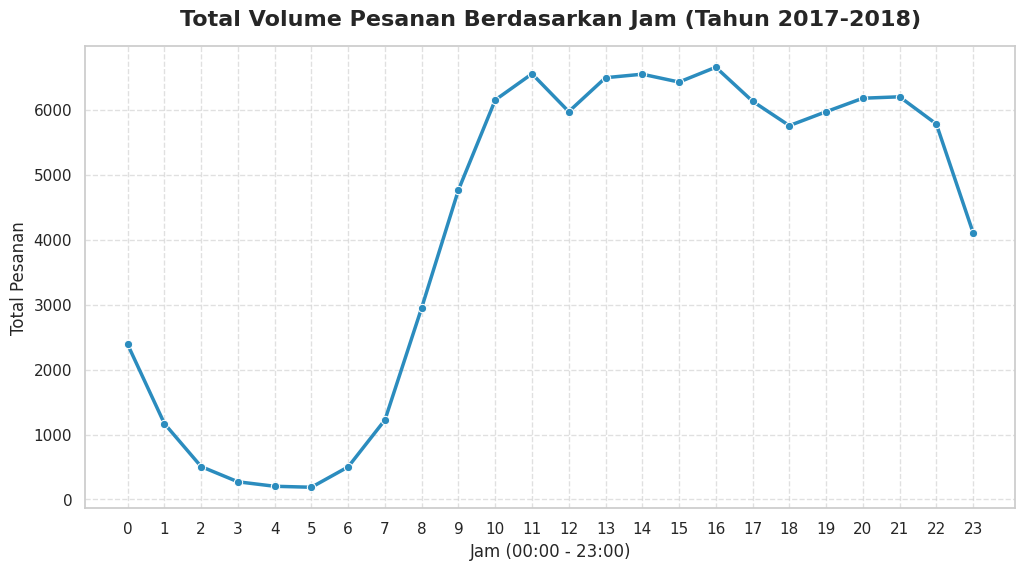

/tmp/ipykernel_20636/3216041080.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_filtered.groupby(['hari_pesanan', 'jam_pesanan'])['order_id'].count().unstack()


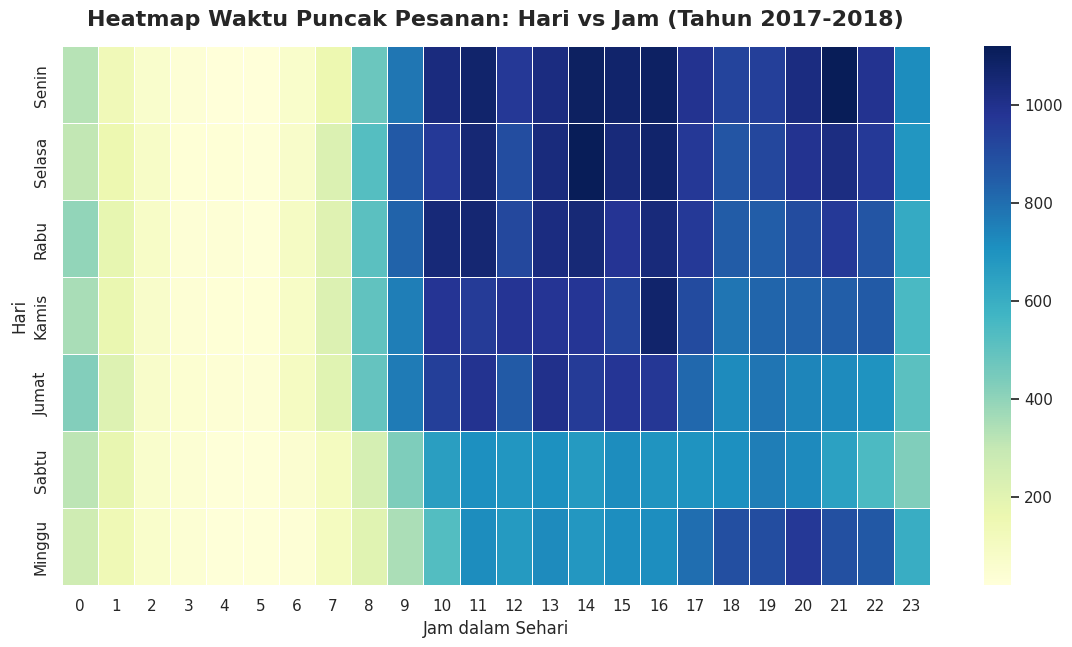

In [31]:
path_orders = f"dataset/olist_orders_dataset.csv"
df_orders = pd.read_csv(path_orders)

df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])

df_filtered = df_orders[df_orders['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()

df_filtered['jam_pesanan'] = df_filtered['order_purchase_timestamp'].dt.hour
df_filtered['hari_pesanan'] = df_filtered['order_purchase_timestamp'].dt.day_name()

urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_filtered['hari_pesanan'] = pd.Categorical(df_filtered['hari_pesanan'], categories=urutan_hari, ordered=True)

plt.figure(figsize=(12, 6))
volume_per_jam = df_filtered.groupby('jam_pesanan')['order_id'].count()

sns.lineplot(x=volume_per_jam.index, y=volume_per_jam.values, marker='o', color='#2b8cbe', linewidth=2.5)
plt.title('Total Volume Pesanan Berdasarkan Jam (Tahun 2017-2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jam (00:00 - 23:00)', fontsize=12)
plt.ylabel('Total Pesanan', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(14, 7))
heatmap_data = df_filtered.groupby(['hari_pesanan', 'jam_pesanan'])['order_id'].count().unstack()

heatmap_data.index = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, linewidths=.5)
plt.title('Heatmap Waktu Puncak Pesanan: Hari vs Jam (Tahun 2017-2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jam dalam Sehari', fontsize=12)
plt.ylabel('Hari', fontsize=12)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_20636/3442473541.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_filtered, x='payment_type', y='payment_value', estimator='mean', errorbar=None, palette='viridis')


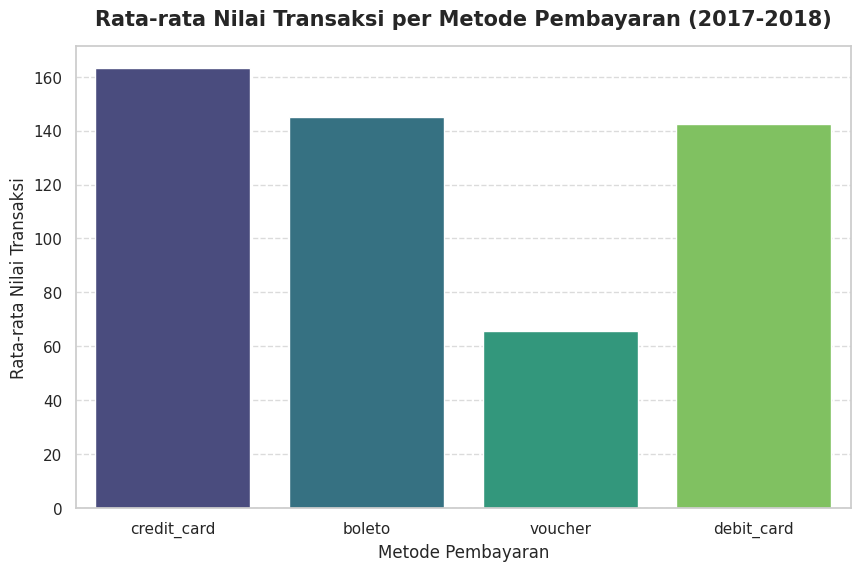

/tmp/ipykernel_20636/3442473541.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='payment_type', y='payment_value', palette='Set2')


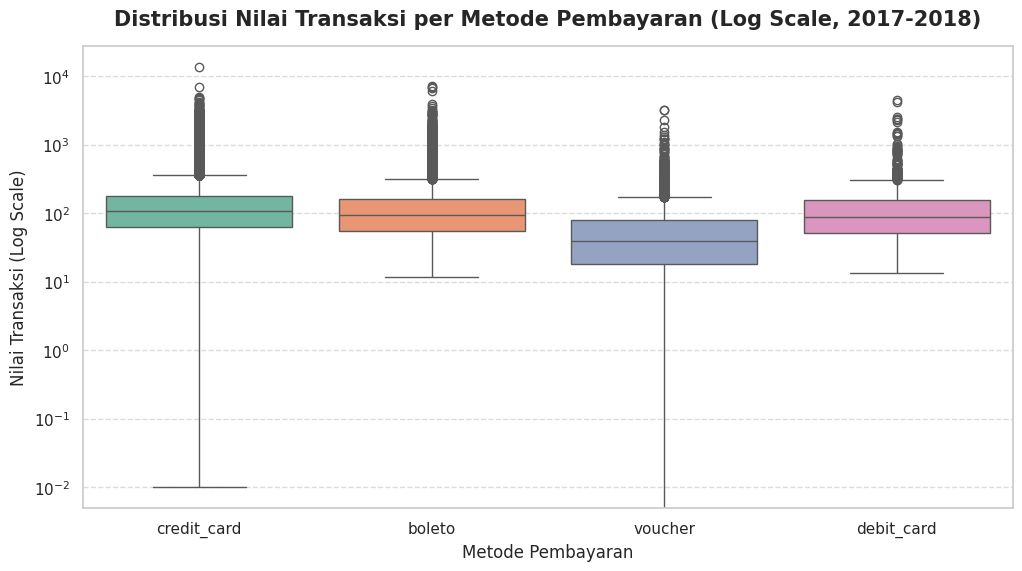

In [32]:
path_orders = f"dataset/olist_orders_dataset.csv"
df_orders = pd.read_csv(path_orders)

path_payments = f"{path}/olist_order_payments_dataset.csv"
df_payments = pd.read_csv(path_payments)

df_merged = pd.merge(df_payments, df_orders[['order_id', 'order_purchase_timestamp']], on='order_id', how='inner')

df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])

df_filtered = df_merged[df_merged['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()

df_filtered = df_filtered[df_filtered['payment_type'] != 'not_defined']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_filtered, x='payment_type', y='payment_value', estimator='mean', errorbar=None, palette='viridis')
plt.title('Rata-rata Nilai Transaksi per Metode Pembayaran (2017-2018)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Rata-rata Nilai Transaksi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='payment_type', y='payment_value', palette='Set2')
plt.title('Distribusi Nilai Transaksi per Metode Pembayaran (Log Scale, 2017-2018)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Metode Pembayaran', fontsize=12)
plt.ylabel('Nilai Transaksi (Log Scale)', fontsize=12)
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**

- Volume pesanan mulai meningkat signifikan sejak jam 07.00 dan mencapai puncak pertama pada jam 10.00–11.00 (6.500 pesanan)
- Setelah sedikit menurun di jam 12.00 (kemungkinan jam makan siang), volume kembali stabil tinggi di rentang jam 13.00–16.00
- Terjadi puncak kedua yang lebih rendah di jam 20.00–21.00, mengindikasikan aktivitas belanja malam hari
- Volume terendah terjadi di jam 04.00–05.00 dini hari
- Dari heatmap, hari kerja (Senin–Kamis) memiliki intensitas tertinggi di jam 10.00–18.00, Jumat aktif hingga jam 17.00 saja, kemungkinan pelanggan mulai tidak aktif menjelang akhir pekan
- Sabtu aktivitas lebih merata dan lebih rendah dibanding hari kerja
- Minggu menariknya aktivitasnya justru bergeser ke malam hari (18.00–22.00), berbeda dari pola hari kerja

- Credit card memiliki rata-rata transaksi tertinggi (163), diikuti boleto (145) dan debit card (142) yang relatif setara, sementara voucher jauh di bawah (65), wajar karena voucher biasanya digunakan sebagai potongan parsial, bukan pembayaran penuh
- Dari boxplot log scale, median credit card, boleto, dan debit card berada di kisaran 100, sedangkan voucher di kisaran 40–50
- Ketiga metode utama memiliki outlier transaksi besar hingga 10.000, menunjukkan ada segmen pelanggan high-value di semua metode
- Boleto memiliki whisker bawah yang sangat panjang (mendekati 0,01), mengindikasikan ada transaksi boleto bernilai nyaris nol yang perlu dicurigai sebagai data anomali
- Voucher memiliki sebaran paling sempit dan nilai paling kecil secara konsisten, memperkuat bahwa voucher berfungsi sebagai pelengkap pembayaran, bukan metode utama

## Conclusion

- Waktu puncak pesanan terjadi pada jam 10.00–16.00 di hari kerja (Senin–Kamis), dengan puncak tertinggi di jam 10.00–11.00 mencapai 6.500 pesanan. Terdapat puncak sekunder yang lebih kecil di jam 20.00–21.00 yang mencerminkan perilaku belanja malam. Hari Minggu menunjukkan pola berbeda, aktivitas bergeser ke malam hari (18.00–22.00) dibanding siang hari seperti hari kerja. Secara keseluruhan, jam 10.00–16.00 pada hari kerja adalah waktu terbaik untuk promosi atau operasional yang membutuhkan traffic tinggi.
- Credit card menjadi metode pembayaran dengan nilai transaksi rata-rata tertinggi, diikuti boleto dan debit card yang setara di kisaran 142–145. Voucher memiliki nilai rata-rata paling rendah karena umumnya digunakan sebagai pelengkap, bukan pembayaran penuh. Semua metode utama menunjukkan adanya segmen pelanggan high-value dengan transaksi hingga 10.000. Secara keseluruhan, credit card bukan hanya metode pembayaran paling populer, tetapi juga menghasilkan nilai transaksi tertinggi, menjadikannya metode yang paling strategis untuk dioptimalkan dari sisi bisnis.

In [33]:
import shutil
shutil.make_archive("dataset", "zip", "dataset")

'/content/dataset.zip'